# Bank marketing: target EDA

UCI Bank Marketing, 45,211 calls, 16 predictors, target `y` = term deposit subscription. [Dataset and definitions](https://archive.ics.uci.edu/dataset/222/bank+marketing). Moro, Rita & Cortez (2014), CC BY 4.0.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, pointbiserialr
from skimpy import skim
from ucimlrepo import fetch_ucirepo
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

dataset = fetch_ucirepo(id=222)
X = dataset.data.features.copy()
y = dataset.data.targets.iloc[:, 0].eq('yes').astype(int)
df = X.assign(y=y)
df['prior_contact'] = np.where(df['pdays'].eq(-1), 'no', 'yes')
df['days_since_prior'] = df['pdays'].where(df['pdays'].ne(-1))
df.shape
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 45211  │ │ string      │ 10    │                                                          │
│ │ Number of columns │ 19     │ │ int64       │ 8     │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━┳━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column           ┃ NA    ┃ NA %             ┃ mean   ┃ sd     ┃ p0    ┃ p25 ┃ p50 ┃ p75  ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━╇━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │       age        │     0 │                0 │  40.94 │  10.62 │    18 │  33 │  39 │   48 │     95 │  ▃█▅▁  │  │
│ │     balance      │     0 │                0 │   1362 │   3045 │ -8019 │  72 │ 448 │ 1428 │ 102100 │   █    │  │
│ │   day_of_week    │     0 │                0 │  15.81 │  8.322 │     1 │   8 │  16 │   21 │     31 │ ▅▆▆█▄▆ │  │
│ │     duration     │     0 │                0 │  258.2 │  257.5 │     0 │ 103 │ 180 │  319 │   4918 │   █    │  │
│ │     campaign     │     0 │                0 │  2.764 │  3.098 │     1 │   1 │   2 │    3 │     63 │   █    │  │
│ │      pdays       │     0 │                0 │   40.2 │  100.1 │    -1 │  -1 │  -1 │   -1 │    871 │  █▁▁   │  │
│ │     previous     │     0 │                0 │ 0.5803 │  2.303 │     0 │   0 │   0 │    0 │    275 │   █    │  │
│ │        y         │     0 │                0 │  0.117 │ 0.3214 │     0 │   0 │   0 │    0 │      1 │ █    ▁ │  │
│ │ days_since_prior │ 36954 │ 81.7367454822941 │  224.6 │  115.3 │     1 │ 133 │ 194 │  327 │    871 │  ▅█▆   │  │
│ │                  │       │                3 │        │        │       │     │     │      │        │        │  │
│ └──────────────────┴───────┴──────────────────┴────────┴────────┴───────┴─────┴─────┴──────┴────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┓  │
│ ┃          ┃       ┃          ┃          ┃          ┃          ┃          ┃ chars per ┃ words    ┃ total     ┃  │
│ ┃ column   ┃ NA    ┃ NA %     ┃ shortest ┃ longest  ┃ min      ┃ max      ┃ row       ┃ per row  ┃ words     ┃  │
│ ┡━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━┩  │
│ │   job    │   288 │ 0.637013 │  admin.  │ self-emp │  admin.  │ unemploy │       9.5 │     0.99 │     44923 │  │
│ │          │       │ 11627701 │          │  loyed   │          │    ed    │           │          │           │  │
│ │          │       │       22 │          │          │          │          │           │          │           │  │
│ │ marital  │     0 │        0 │  single  │ divorced │ divorced │  single  │      6.83 │        1 │     45211 │  │
│ │ educatio │  1857 │ 4.107407 │ primary  │ secondar │ primary  │ tertiary │      8.38 │     0.96 │     43354 │  │
│ │    n     │       │ 48932781 │          │    y     │ 

## Class balance and data quality

In [2]:
balance = df['y'].value_counts().rename(index={0: 'no', 1: 'yes'}).to_frame('count')
balance['share'] = (balance['count'] / len(df)).round(4)
display(balance)
display(X.isna().sum().loc[lambda s: s.gt(0)].sort_values(ascending=False).to_frame('missing'))
print('Duplicate complete rows:', df[X.columns.tolist() + ['y']].duplicated().sum())
print('pdays = -1 (no prior contact):', df['pdays'].eq(-1).sum())

,count,share
y,,
no,39922,0.883
yes,5289,0.117


,missing
poutcome,36959
contact,13020
education,1857
job,288


Duplicate complete rows: 0
pdays = -1 (no prior contact): 36954


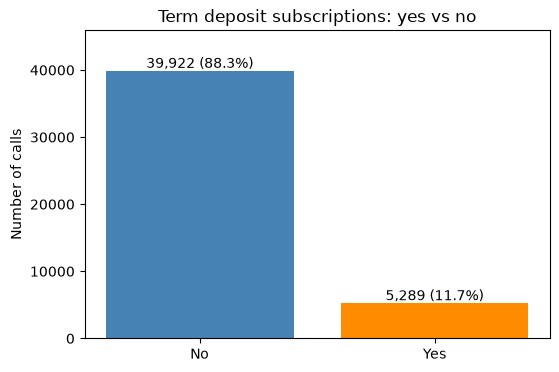

No-to-yes ratio: 7.5:1


In [3]:
counts = y.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No', 'Yes'], counts, color=['steelblue', 'darkorange'])
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, count + 400,
            f'{count:,} ({count/len(y):.1%})', ha='center')
ax.set(title='Term deposit subscriptions: yes vs no', ylabel='Number of calls', ylim=(0, counts.max()*1.15))
plt.show()
print(f'No-to-yes ratio: {counts.loc[0]/counts.loc[1]:.1f}:1')

## Feature overview

The histograms show overall counts. Balance uses its 1st–99th percentile range; duration and campaign stop at the 99th percentile for readability.

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.9,10.6,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.3,3044.8,-8019.0,72.0,448.0,1428.0,102127.0
day_of_week,45211.0,15.8,8.3,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.2,257.5,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.8,3.1,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.2,100.1,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.6,2.3,0.0,0.0,0.0,0.0,275.0


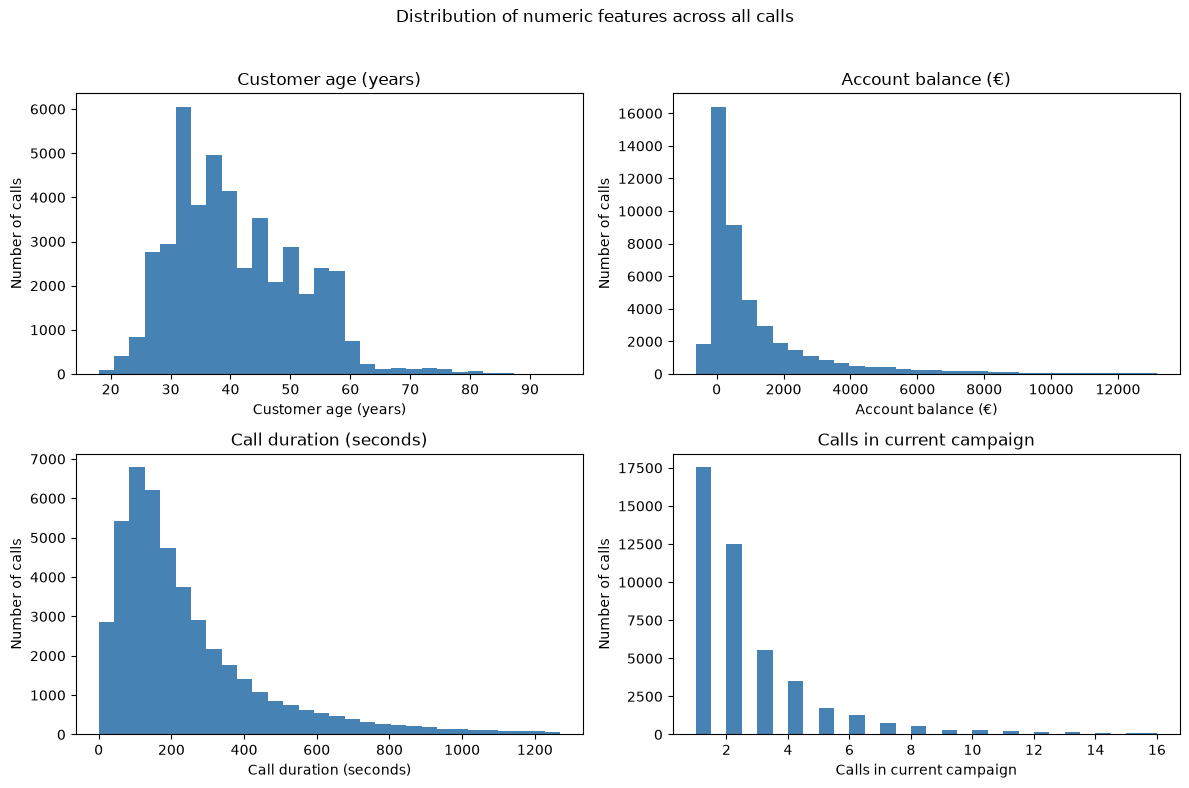

In [4]:
display(X.select_dtypes(include='number').describe().T.round(1))
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
labels = {'age': 'Customer age (years)', 'balance': 'Account balance (€)',
          'duration': 'Call duration (seconds)', 'campaign': 'Calls in current campaign'}
for ax, feature in zip(axes.flat, labels):
    lower = X[feature].quantile(0.01) if feature == 'balance' else X[feature].min()
    upper = X[feature].max() if feature == 'age' else X[feature].quantile(0.99)
    ax.hist(X[feature], bins=np.linspace(lower, upper, 31), color='steelblue')
    ax.set(title=labels[feature], xlabel=labels[feature], ylabel='Number of calls')
fig.suptitle('Distribution of numeric features across all calls')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

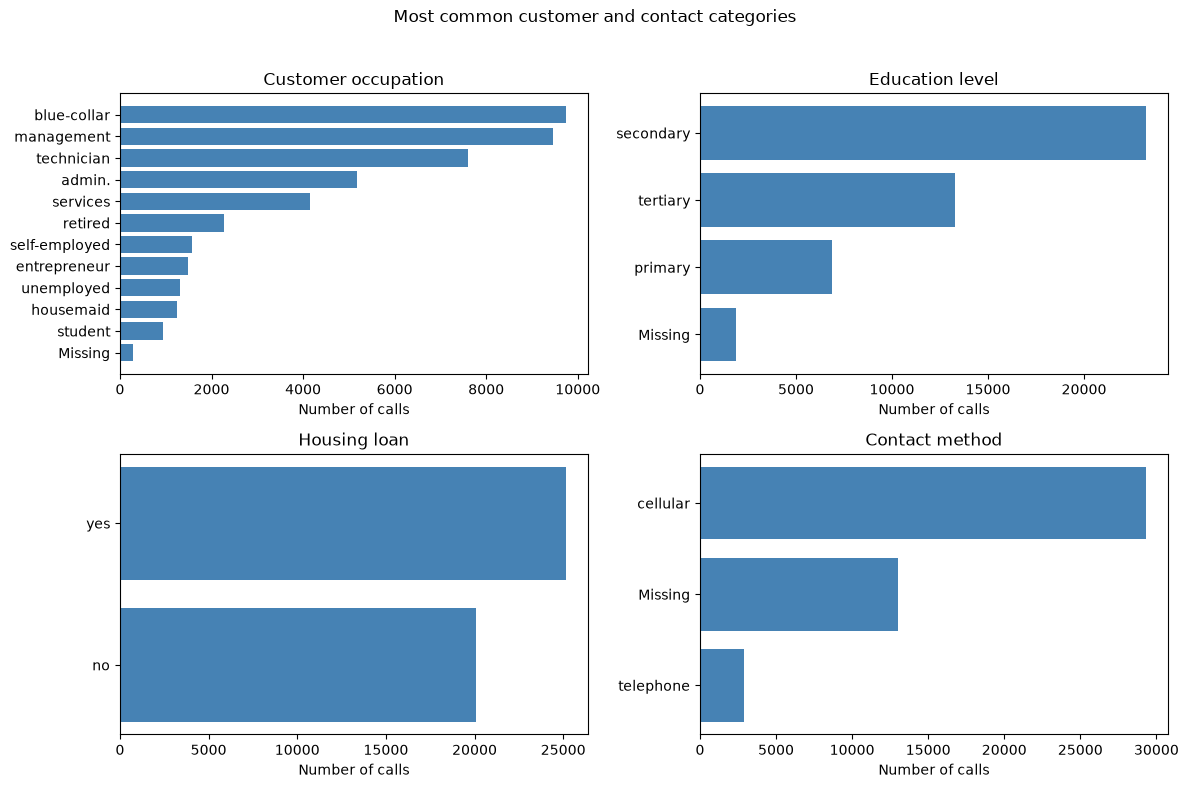

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
labels = {'job': 'Customer occupation', 'education': 'Education level',
          'housing': 'Housing loan', 'contact': 'Contact method'}
for ax, feature in zip(axes.flat, labels):
    counts = X[feature].fillna('Missing').value_counts().sort_values()
    ax.barh(counts.index.astype(str), counts.values, color='steelblue')
    ax.set(title=labels[feature], xlabel='Number of calls')
fig.suptitle('Most common customer and contact categories')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

`pdays = -1` means no prior contact; it is split into a contact flag and elapsed days. Missing `poutcome` and `contact` values are retained as separate categories.

In [6]:
def rates(feature):
    return (df.assign(group=df[feature].fillna('Missing'))
              .groupby('group')['y'].agg(n='size', yes='sum', rate='mean')
              .sort_values('rate', ascending=False))

for feature in ['poutcome', 'contact', 'month', 'housing', 'loan', 'job']:
    print(feature)
    display(rates(feature).assign(rate=lambda t: (100*t.rate).round(1)).rename(columns={'rate': 'yes_pct'}))

poutcome


,n,yes,yes_pct
group,,,
success,1511,978,64.7
other,1840,307,16.7
failure,4901,618,12.6
Missing,36959,3386,9.2


contact


,n,yes,yes_pct
group,,,
cellular,29285,4369,14.9
telephone,2906,390,13.4
Missing,13020,530,4.1


month


...

,n,yes,yes_pct
group,,,
no,20081,3354,16.7
yes,25130,1935,7.7


loan


,n,yes,yes_pct
group,,,
no,37967,4805,12.7
yes,7244,484,6.7


job


,n,yes,yes_pct
group,,,
student,938,269,28.7
retired,2264,516,22.8
unemployed,1303,202,15.5
management,9458,1301,13.8
admin.,5171,631,12.2
self-employed,1579,187,11.8
Missing,288,34,11.8
technician,7597,840,11.1
services,4154,369,8.9


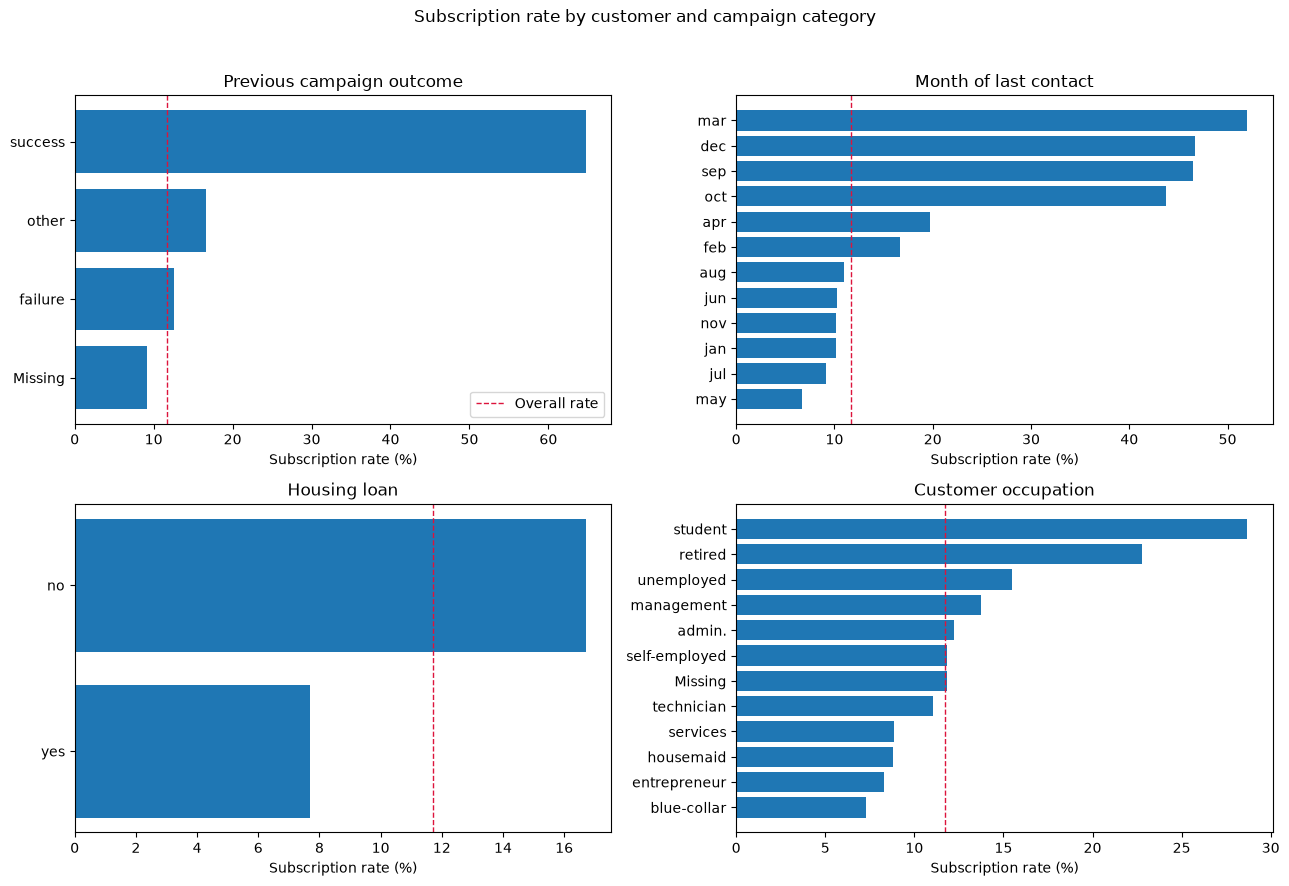

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
labels = {'poutcome': 'Previous campaign outcome', 'month': 'Month of last contact',
          'housing': 'Housing loan', 'job': 'Customer occupation'}
for ax, feature in zip(axes.flat, labels):
    summary = rates(feature).sort_values('rate')
    ax.barh(summary.index.astype(str), summary['rate'] * 100)
    ax.axvline(y.mean() * 100, color='crimson', linestyle='--', linewidth=1, label='Overall rate')
    ax.set(xlabel='Subscription rate (%)', title=labels[feature])
axes[0, 0].legend(loc='lower right')
fig.suptitle('Subscription rate by customer and campaign category')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [8]:
bins = {
    'age': [18, 30, 40, 50, 60, 100],
    'duration': [0, 60, 120, 300, 600, np.inf],
    'campaign': [0, 1, 2, 3, 5, 10, np.inf],
    'balance': [-np.inf, 0, 500, 1500, 5000, np.inf],
}
for feature, edges in bins.items():
    print(feature)
    display(df.groupby(pd.cut(df[feature], edges, include_lowest=True), observed=True)['y']
            .agg(n='size', yes_pct=lambda s: round(100*s.mean(), 1)))

age


,n,yes_pct
age,,
"(17.999, 30.0]",7030,16.3
"(30.0, 40.0]",17687,10.2
"(40.0, 50.0]",11239,9.1
"(50.0, 60.0]",8067,10.1
"(60.0, 100.0]",1188,42.3


duration


,n,yes_pct
duration,,
"(-0.001, 60.0]",4766,0.2
"(60.0, 120.0]",9278,2.2
"(120.0, 300.0]",18893,8.6
"(300.0, 600.0]",8484,19.2
"(600.0, inf]",3790,48.4


campaign


,n,yes_pct
campaign,,
"(-0.001, 1.0]",17544,14.6
"(1.0, 2.0]",12505,11.2
"(2.0, 3.0]",5521,11.2
"(3.0, 5.0]",5286,8.6
"(5.0, 10.0]",3159,6.5
"(10.0, inf]",1196,3.9


balance


,n,yes_pct
balance,,
"(-inf, 0.0]",7280,6.9
"(0.0, 500.0]",16385,10.3
"(500.0, 1500.0]",10651,12.5
"(1500.0, 5000.0]",8050,16.6
"(5000.0, inf]",2845,15.5


## Histograms by target

Each class is scaled to 100% to make its shape comparable.

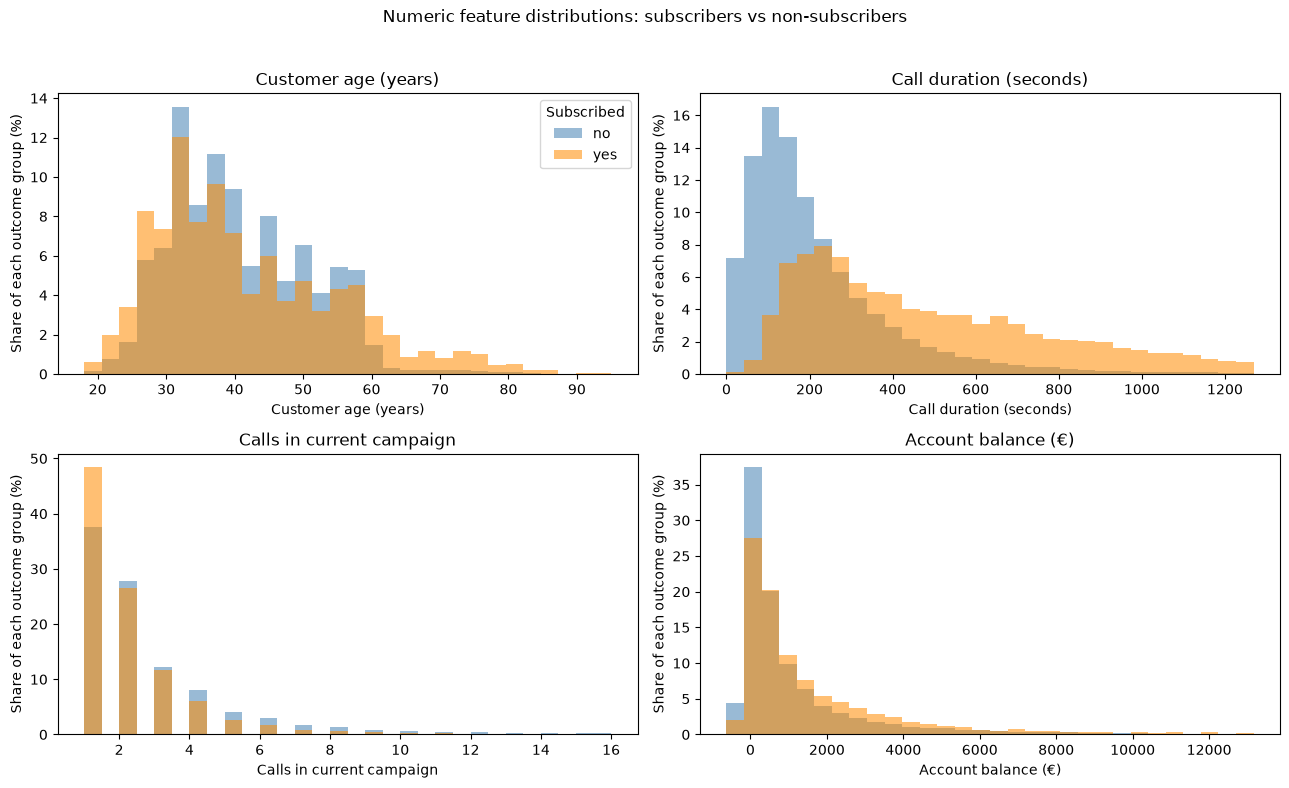

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
labels = {'age': 'Customer age (years)', 'duration': 'Call duration (seconds)',
          'campaign': 'Calls in current campaign', 'balance': 'Account balance (€)'}
for ax, feature in zip(axes.flat, bins):
    lower = df[feature].quantile(0.01) if feature == 'balance' else df[feature].min()
    upper = df[feature].quantile(0.99) if feature != 'age' else df[feature].max()
    edges = np.linspace(lower, upper, 31)
    for outcome, label, color in [(0, 'no', 'steelblue'), (1, 'yes', 'darkorange')]:
        values = df.loc[df['y'].eq(outcome), feature]
        ax.hist(values, bins=edges, weights=np.full(len(values), 100 / len(values)),
                alpha=0.55, label=label, color=color)
    ax.set(title=labels[feature], xlabel=labels[feature], ylabel='Share of each outcome group (%)')
axes[0, 0].legend(title='Subscribed')
fig.suptitle('Numeric feature distributions: subscribers vs non-subscribers')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()